# SIGNAL PROCESSING TUTORIAL
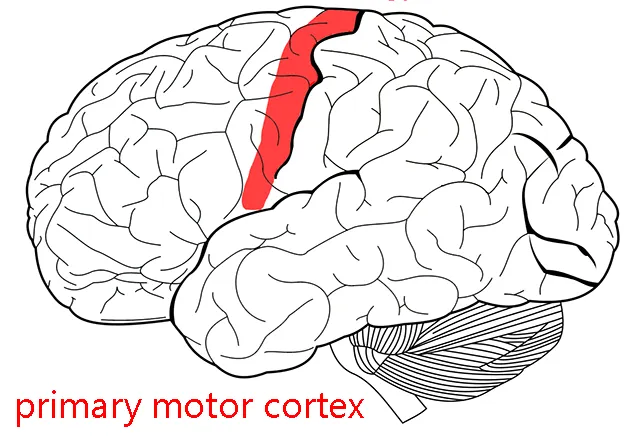
> Right-Hemisphere M1 Hand Knob


## Topics covered

  0.  Imports & data loading
  1.  Resampling / decimation
  2.  Linear filtering: IIR Butterworth (low-pass, high-pass, band-pass)
  3.  Linear filtering: FIR (firwin / window design)
  4.  filtfilt vs lfilter: phase delay demo + Gustafsson's edge method
  5.  Non-linear filtering: Median & Savitzky-Golay
  6.  Convolution for time-series (box, Hanning, Gaussian, derivative kernels)
  7.  Frequency-swept signals (chirp)
  8.  Kalman filter (1-D scalar, hand-rolled)
  9.  Z-score normalisation
  10. Power Spectral Density: Welch's method
  11. Beta-band power ratio 
  12. Spectrogram computation





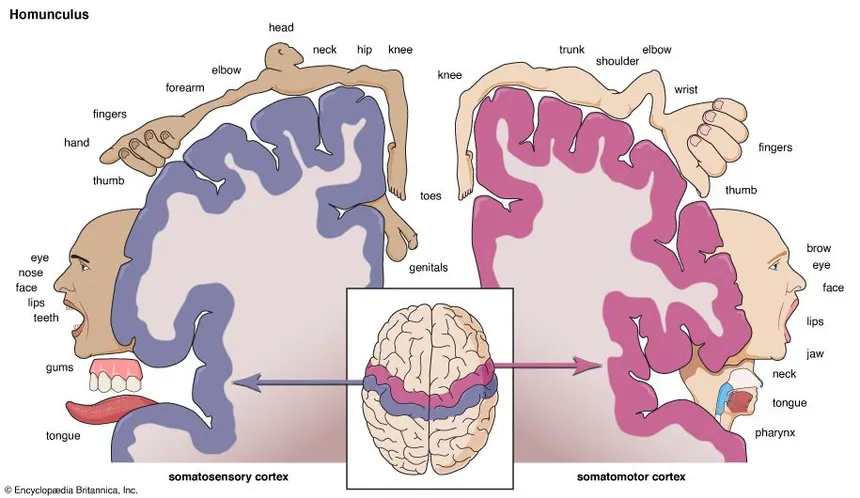

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 0 — IMPORTS & DATA LOADING
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal
from scipy.ndimage import median_filter
from pathlib import Path
import warnings
import timeit

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.autolayout': True,
})

# ── Configuration ──────────────────────────────────────────────────────────────
DATA_DIR  = Path("./time_series_M1_hand_knob")
ORIG_FS   = 500.0   # original sampling rate from LCMV pipeline (Hz)
TARGET_FS = 250.0   # target after decimation (Hz)

# ── Load data ─────────────────────────────────────────────────────────────────
rest_raw = np.load(DATA_DIR / "R_M1_hand_knob_voxel_EyesClosed_Rest.npy")
move_raw = np.load(DATA_DIR / "R_M1_hand_knob_voxel_LeftHand_Move.npy")

  M1 Hand-Knob Signal Processing Tutorial
  Rest :   7500 samples  (15.0 s)  min=-1.077  max=1.265
  Move :   7500 samples  (15.0 s)  min=-0.972  max=0.971


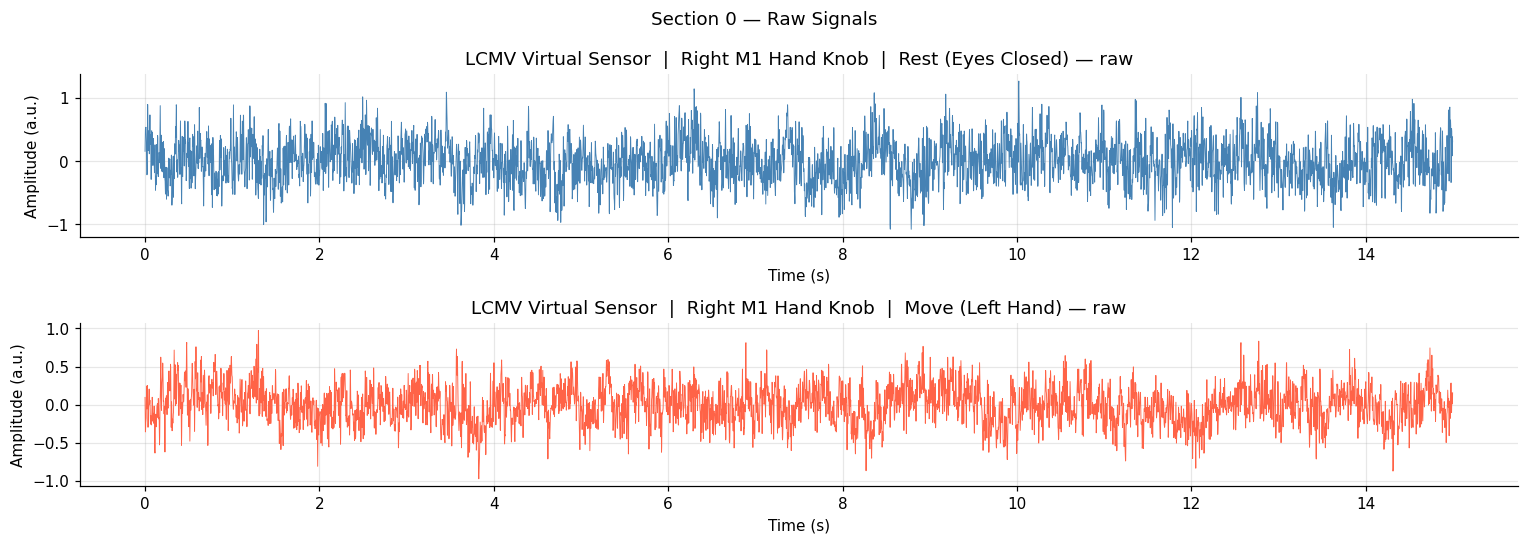

In [4]:
print("=" * 60)
print("  M1 Hand-Knob Signal Processing Tutorial")
print("=" * 60)
print(f"  Rest : {rest_raw.shape[0]:>6} samples  "
      f"({rest_raw.shape[0]/ORIG_FS:.1f} s)  "
      f"min={rest_raw.min():.3f}  max={rest_raw.max():.3f}")
print(f"  Move : {move_raw.shape[0]:>6} samples  "
      f"({move_raw.shape[0]/ORIG_FS:.1f} s)  "
      f"min={move_raw.min():.3f}  max={move_raw.max():.3f}")

fig, axes = plt.subplots(2, 1, figsize=(14, 5))
for ax, sig_data, lbl, col in zip(
        axes,
        [rest_raw, move_raw],
        ["Rest (Eyes Closed) — raw", "Move (Left Hand) — raw"],
        ["steelblue", "tomato"]):
    t = np.arange(len(sig_data)) / ORIG_FS
    ax.plot(t, sig_data, lw=0.6, color=col)
    ax.set_title(f"LCMV Virtual Sensor  |  Right M1 Hand Knob  |  {lbl}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (a.u.)")
plt.suptitle("Section 0 — Raw Signals", fontsize=12)
plt.show()

## SECTION 1: RESAMPLING (DECIMATION)

**Resample:**
  500 Hz → 250 Hz halves data size. Nyquist at 250 Hz = 125 Hz, well above our analysis band (1–45 Hz).

Aliasing: naively dropping every other sample folds high-freq content down.

> scipy.signal.decimate applies an anti-aliasing LPF *before* subsampling.
> zero_phase=True  → no event-time shift

In [5]:
q         = int(ORIG_FS / TARGET_FS)   # downsampling factor = 2
rest_dec  = signal.decimate(rest_raw, q, ftype='iir', zero_phase=True)
move_dec  = signal.decimate(move_raw, q, ftype='iir', zero_phase=True)

print(f"\n[Decimation]  {rest_raw.shape[0]} samples @ {int(ORIG_FS)} Hz  →  "
      f"{rest_dec.shape[0]} samples @ {int(TARGET_FS)} Hz  (q={q})")



[Decimation]  7500 samples @ 500 Hz  →  3750 samples @ 250 Hz  (q=2)


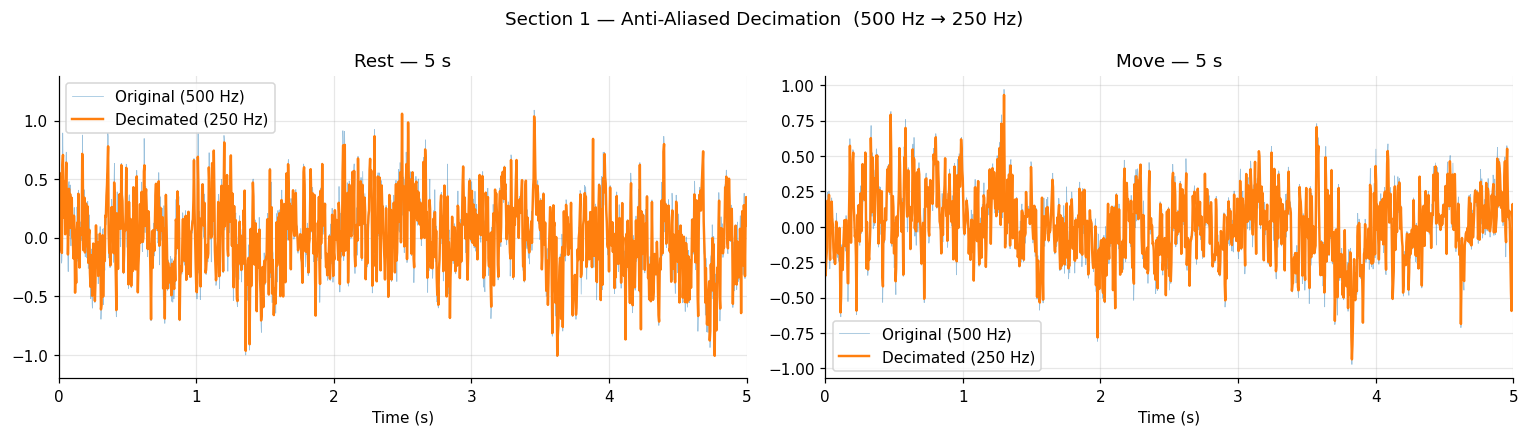

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, raw, dec, lbl in zip(
        axes,
        [rest_raw, move_raw],
        [rest_dec, move_dec],
        ["Rest", "Move"]):
    t_o = np.arange(len(raw)) / ORIG_FS
    t_d = np.arange(len(dec)) / TARGET_FS
    ax.plot(t_o, raw, lw=0.5, alpha=0.45, label=f"Original ({int(ORIG_FS)} Hz)")
    ax.plot(t_d, dec, lw=1.6,             label=f"Decimated ({int(TARGET_FS)} Hz)")
    ax.set_xlim(0, 5)
    ax.set_title(f"{lbl} — 5 s")
    ax.set_xlabel("Time (s)")
    ax.legend()
plt.suptitle("Section 1 — Anti-Aliased Decimation  (500 Hz → 250 Hz)", fontsize=12)
plt.show()

## SECTION 2: LINEAR FILTERING: IIR BUTTERWORTH

- IIR = Infinite Impulse Response, uses feedback (poles).
- Butterworth: maximally flat passband ("no ripple").
- SOS (Second-Order Sections) form is numerically stable for high orders.



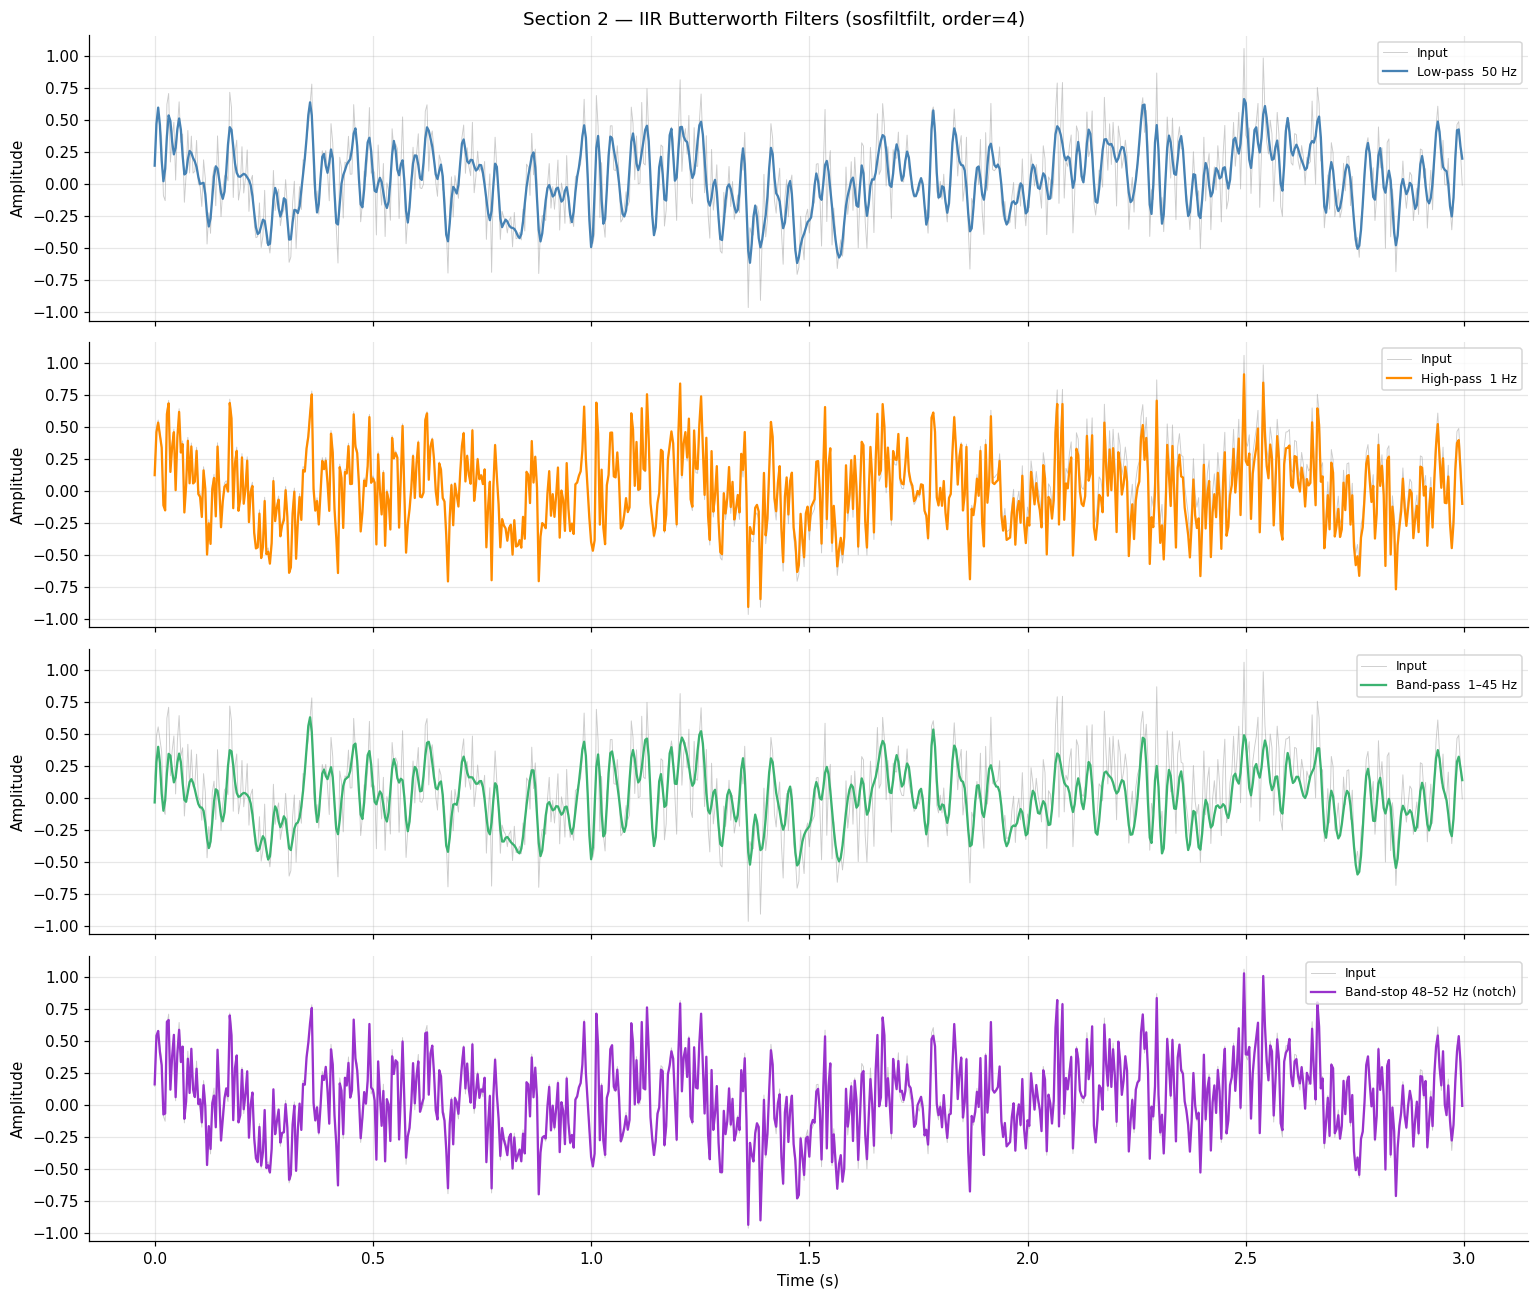

In [7]:
def butter_filter(data_in, fs, btype, cutoff, order=4):
    """Generic Butterworth via sosfiltfilt (zero-phase, stable SOS)."""
    nyq = 0.5 * fs
    if isinstance(cutoff, (list, tuple)):
        wn = [c / nyq for c in cutoff]
    else:
        wn = cutoff / nyq
    sos = signal.butter(order, wn, btype=btype, output='sos')
    return signal.sosfiltfilt(sos, data_in)

x = rest_dec   # working signal for this section

lp  = butter_filter(x, TARGET_FS, 'lowpass',  50.0)
hp  = butter_filter(x, TARGET_FS, 'highpass',  1.0)
bp  = butter_filter(x, TARGET_FS, 'bandpass', [1.0, 45.0])
bs  = butter_filter(x, TARGET_FS, 'bandstop', [48.0, 52.0])   # 50 Hz notch

t    = np.arange(len(x)) / TARGET_FS
wn3  = slice(0, int(3 * TARGET_FS))

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
specs = [
    (lp, "Low-pass  50 Hz",          "steelblue"),
    (hp, "High-pass  1 Hz",           "darkorange"),
    (bp, "Band-pass  1–45 Hz",        "mediumseagreen"),
    (bs, "Band-stop 48–52 Hz (notch)","darkorchid"),
]
for ax, (filt, lbl, col) in zip(axes, specs):
    ax.plot(t[wn3], x[wn3],    lw=0.6, alpha=0.4, color='gray', label='Input')
    ax.plot(t[wn3], filt[wn3], lw=1.5, color=col,              label=lbl)
    ax.set_ylabel("Amplitude")
    ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel("Time (s)")
plt.suptitle("Section 2 — IIR Butterworth Filters (sosfiltfilt, order=4)", fontsize=12)
plt.show()


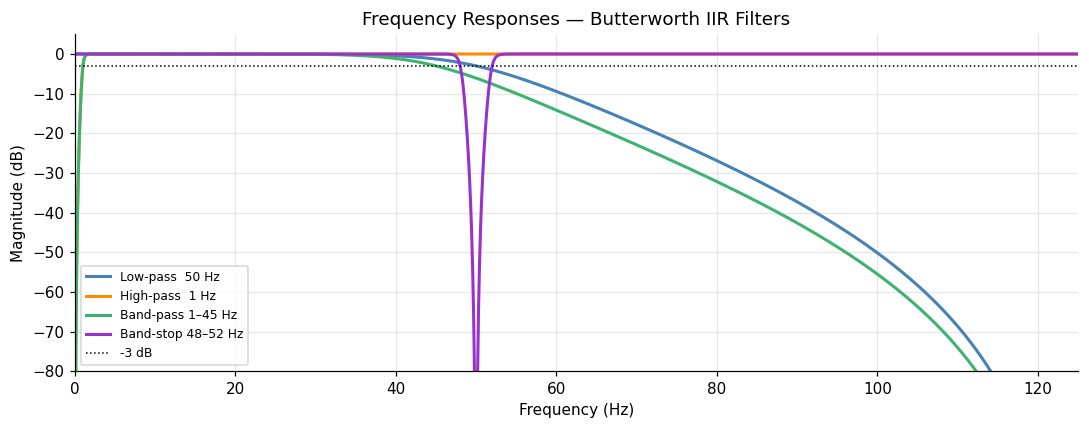

In [8]:
# ── Frequency responses ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
filter_specs = [
    ('lowpass',  50.0,         "Low-pass  50 Hz",   "steelblue"),
    ('highpass',  1.0,         "High-pass  1 Hz",   "darkorange"),
    ('bandpass', [1.0, 45.0],  "Band-pass 1–45 Hz", "mediumseagreen"),
    ('bandstop', [48.0, 52.0], "Band-stop 48–52 Hz","darkorchid"),
]
for btype, cutoff, lbl, col in filter_specs:
    nyq = 0.5 * TARGET_FS
    wn  = [c / nyq for c in cutoff] if isinstance(cutoff, list) else cutoff / nyq
    sos = signal.butter(4, wn, btype=btype, output='sos')
    w, h = signal.sosfreqz(sos, worN=2048, fs=TARGET_FS)
    ax.plot(w, 20*np.log10(np.abs(h)+1e-12), lw=2, label=lbl, color=col)
ax.axhline(-3, color='black', ls=':', lw=1, label='-3 dB')
ax.set_xlim(0, TARGET_FS/2)
ax.set_ylim(-80, 5)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.legend(fontsize=8)
ax.set_title("Frequency Responses — Butterworth IIR Filters")
plt.show()


## SECTION 3: LINEAR FILTERING: FIR (WINDOW DESIGN)

- FIR = Finite Impulse Response, no feedback, always stable.
- Window design (firwin): choose a window shape to control stop-band roll-off.

### Window trade-offs:
- Rectangular: sharpest transition, worst side-lobes
- Hann / Hanning: good general purpose
- Kaiser(β): tunable, higher β → more attenuation, wider transition band
- Blackman: excellent attenuation, moderate transition width

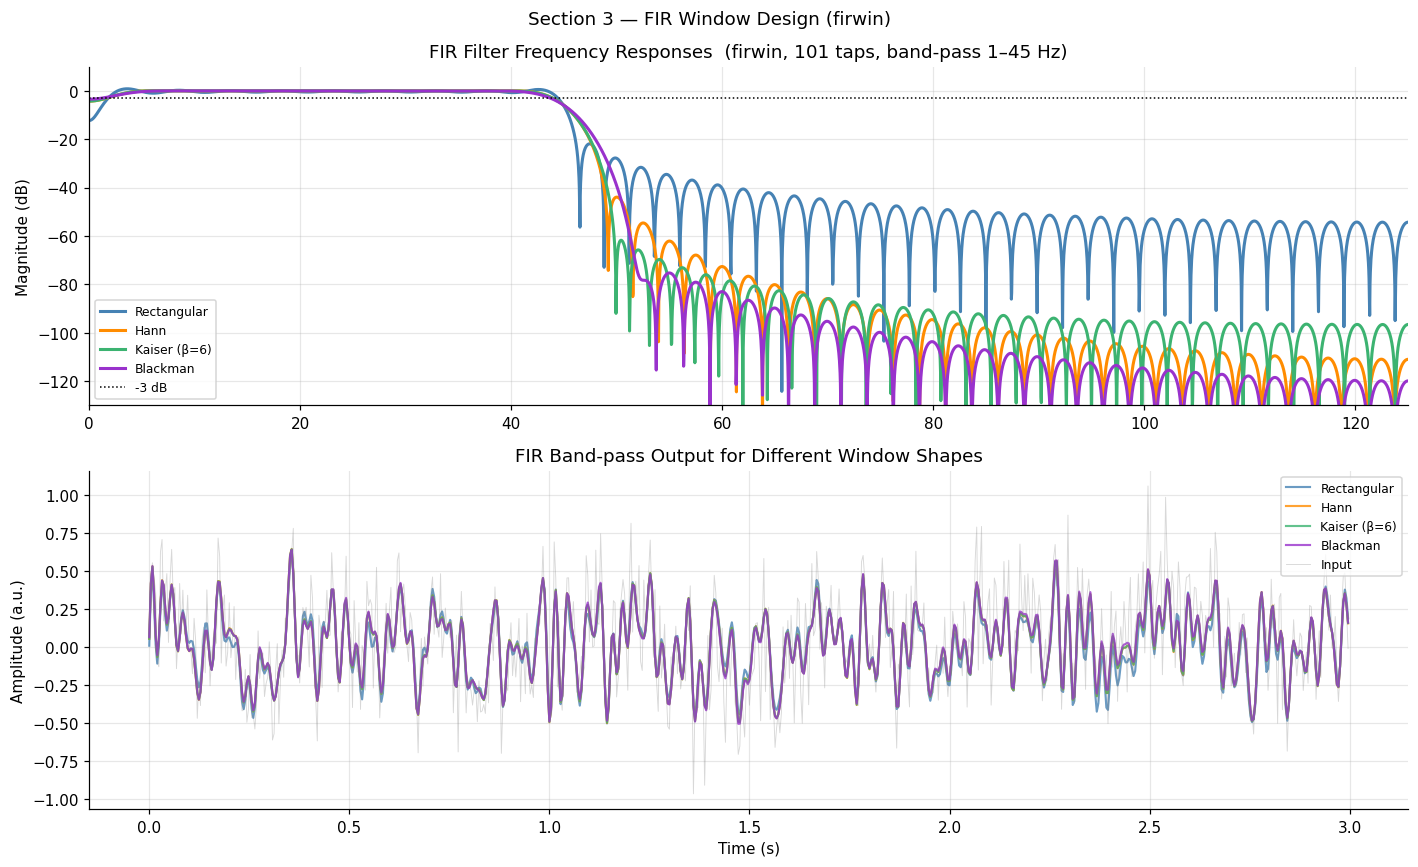

In [9]:
numtaps = 101   # must be odd for linear phase; longer → sharper cut-off

windows = ['rectangular', 'hann', ('kaiser', 6.0), 'blackman']
window_labels = ['Rectangular', 'Hann', 'Kaiser (β=6)', 'Blackman']
colors = ['steelblue', 'darkorange', 'mediumseagreen', 'darkorchid']

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

for win, lbl, col in zip(windows, window_labels, colors):
    taps = signal.firwin(numtaps, [1.0/(TARGET_FS/2), 45.0/(TARGET_FS/2)],
                         pass_zero=False, window=win)
    w, h = signal.freqz(taps, 1.0, worN=4096, fs=TARGET_FS)

    axes[0].plot(w, 20*np.log10(np.abs(h)+1e-12), lw=2, label=lbl, color=col)
    y_fir = signal.filtfilt(taps, 1.0, rest_dec)
    axes[1].plot(t[wn3], y_fir[wn3], lw=1.4, alpha=0.8, label=lbl, color=col)

axes[0].axhline(-3, color='black', ls=':', lw=1, label='-3 dB')
axes[0].set_xlim(0, TARGET_FS/2)
axes[0].set_ylim(-130, 10)
axes[0].set_ylabel("Magnitude (dB)")
axes[0].set_title(f"FIR Filter Frequency Responses  (firwin, {numtaps} taps, band-pass 1–45 Hz)")
axes[0].legend(fontsize=8)

axes[1].plot(t[wn3], rest_dec[wn3], lw=0.6, alpha=0.3, color='gray', label='Input')
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude (a.u.)")
axes[1].set_title("FIR Band-pass Output for Different Window Shapes")
axes[1].legend(fontsize=8)

plt.suptitle("Section 3 — FIR Window Design (firwin)", fontsize=12)
plt.show()

## SECTION 4: filtfilt vs lfilter + GUSTAFSSON EDGE METHOD

- lfilter, causal (real-time safe) but introduces phase delay: events appear shifted rightward in time → bad for connectivity.
- filtfilt: applies filter forward then backward → zero phase, 2× effective order.
- Gustafsson's method: chooses initial conditions so forward-backward and backward-forward passes agree → minimises edge artefacts.

In [10]:
b_demo, a_demo = signal.butter(4, [1.0/(TARGET_FS/2), 45.0/(TARGET_FS/2)], btype='band')

rest_causal    = signal.lfilter(b_demo, a_demo, rest_dec)
rest_zerophase = signal.filtfilt(b_demo, a_demo, rest_dec)
rest_gust      = signal.filtfilt(b_demo, a_demo, rest_dec, method='gust')



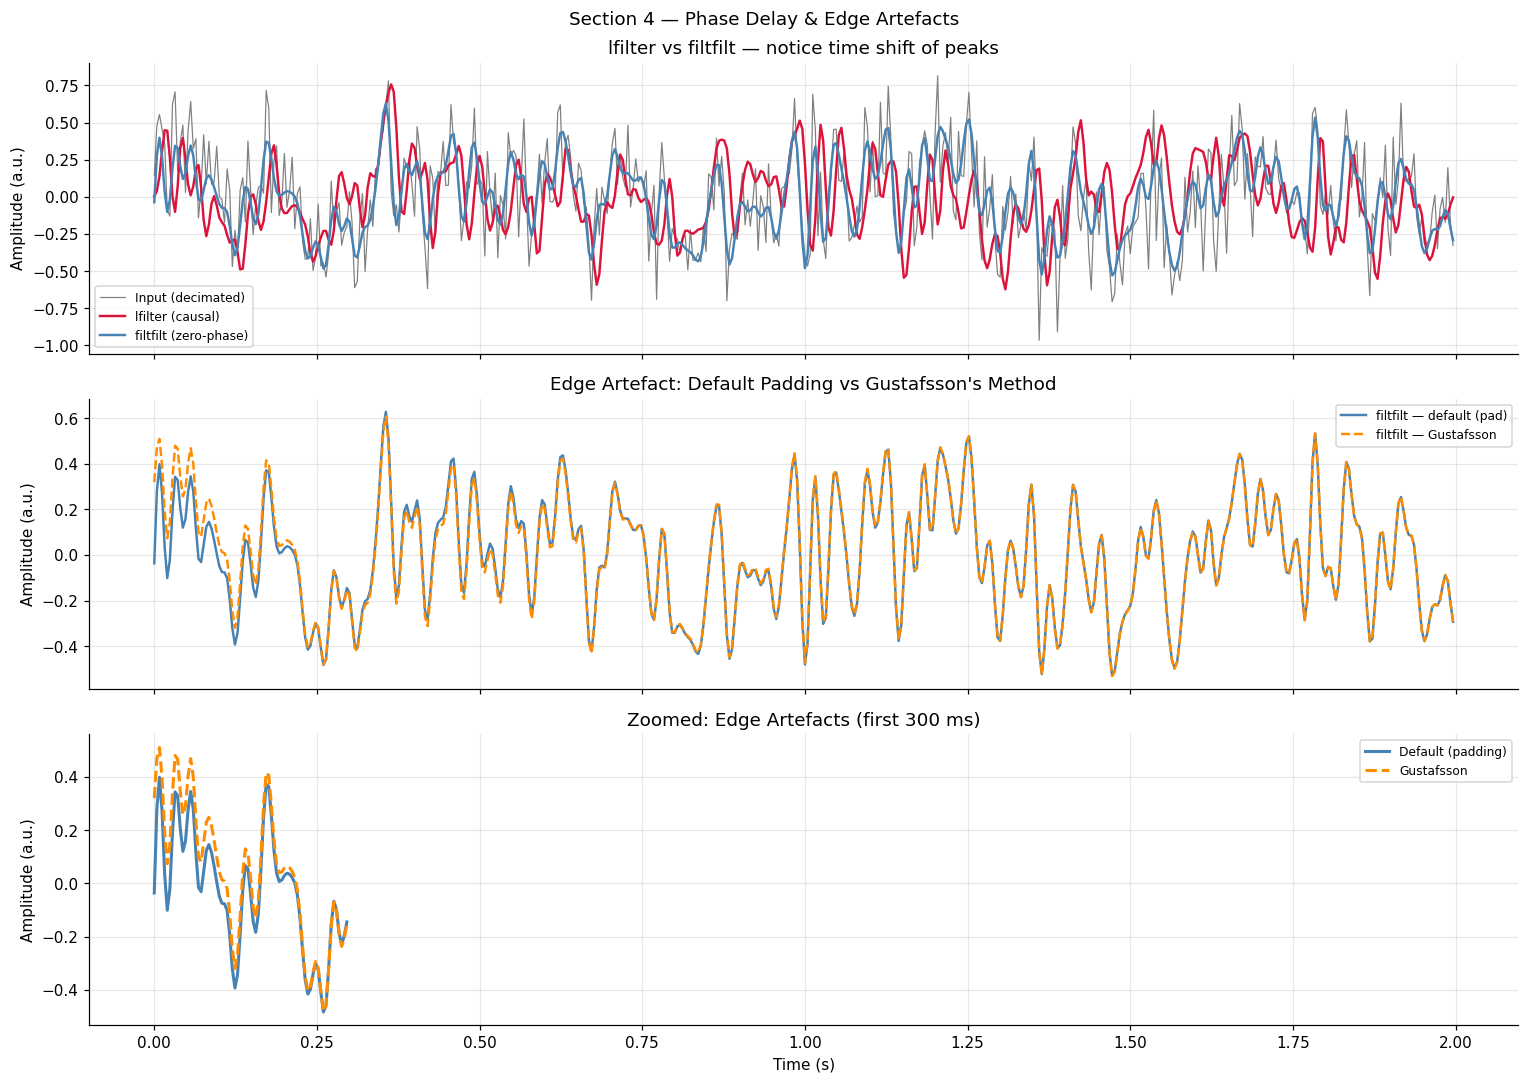

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
seg = slice(0, int(2.0 * TARGET_FS))

axes[0].plot(t[seg], rest_dec[seg],       lw=0.8, color='gray',        label='Input (decimated)')
axes[0].plot(t[seg], rest_causal[seg],    lw=1.6, color='crimson',     label='lfilter (causal)')
axes[0].plot(t[seg], rest_zerophase[seg], lw=1.6, color='steelblue',   label='filtfilt (zero-phase)')
axes[0].set_title("lfilter vs filtfilt — notice time shift of peaks")
axes[0].legend(fontsize=8)

axes[1].plot(t[seg], rest_zerophase[seg], lw=1.6, color='steelblue',  label='filtfilt — default (pad)')
axes[1].plot(t[seg], rest_gust[seg],      lw=1.6, color='darkorange', ls='--', label="filtfilt — Gustafsson")
axes[1].set_title("Edge Artefact: Default Padding vs Gustafsson's Method")
axes[1].legend(fontsize=8)

# Zoomed in at the very start to show edge artefacts
edge = slice(0, int(0.3 * TARGET_FS))
axes[2].plot(t[edge], rest_zerophase[edge], lw=2.0, color='steelblue',  label='Default (padding)')
axes[2].plot(t[edge], rest_gust[edge],      lw=2.0, color='darkorange', ls='--', label="Gustafsson")
axes[2].set_title("Zoomed: Edge Artefacts (first 300 ms)")
axes[2].set_xlabel("Time (s)")
axes[2].legend(fontsize=8)

for ax in axes:
    ax.set_ylabel("Amplitude (a.u.)")

plt.suptitle("Section 4 — Phase Delay & Edge Artefacts", fontsize=12)
plt.show()

# Use zero-phase SOS form for the rest of the tutorial
rest_filt = butter_filter(rest_dec, TARGET_FS, 'bandpass', [1.0, 45.0])
move_filt = butter_filter(move_dec, TARGET_FS, 'bandpass', [1.0, 45.0])

## SECTION 5: NON-LINEAR FILTERING: MEDIAN & SAVITZKY-GOLAY

### Median filter:
-   y[n] = median{ x[n-k/2], …, x[n+k/2] }
-   Non-linear → superposition does NOT hold.
-   Best at removing impulsive ("salt-and-pepper") noise while preserving edges.

### Savitzky-Golay filter:
-   Fits a polynomial of degree p to a sliding window of length w,
-   returns the polynomial value at the centre point.
-   Preserves peak heights and shapes better than a plain moving average.
-   Can also return derivatives (velocity, acceleration) by differentiating the fitted polynomial.

In [12]:
# Inject synthetic artefact spikes for demonstration
rng        = np.random.default_rng(42)
rest_noisy = rest_filt.copy()
spike_idx  = rng.integers(50, len(rest_noisy) - 50, size=30)
rest_noisy[spike_idx] += rng.choice([-1, 1], size=30) * rest_noisy.std() * 8

k_med       = 5   # kernel = 5 samples = 20 ms at 250 Hz
rest_median = median_filter(rest_noisy, size=k_med)
rest_savgol = signal.savgol_filter(rest_noisy, window_length=11, polyorder=3)

# Also show SG derivative (instantaneous slope of the signal)
rest_sg_deriv = signal.savgol_filter(rest_filt, window_length=11, polyorder=3, deriv=1, delta=1/TARGET_FS)

t   = np.arange(len(rest_filt)) / TARGET_FS
wn3 = slice(0, int(3 * TARGET_FS))

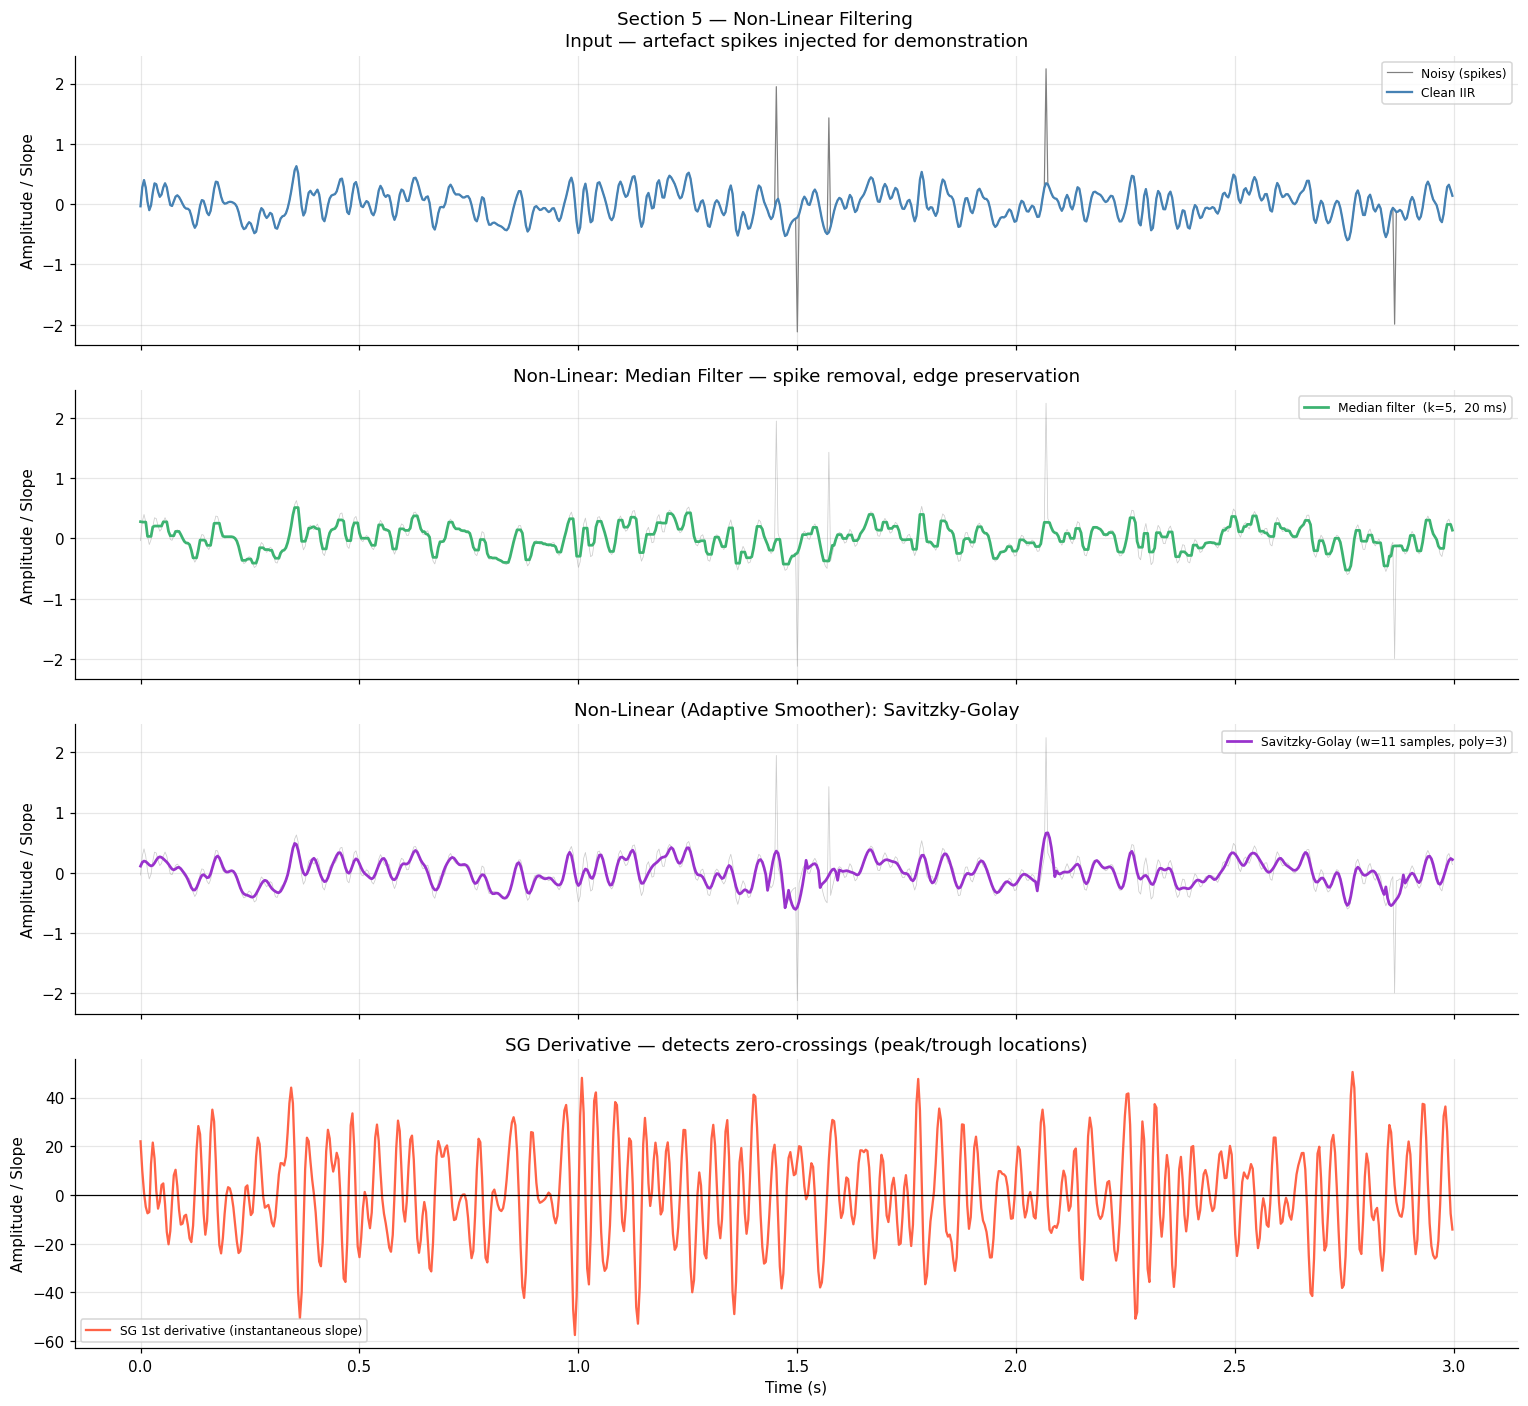

In [13]:
fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=True)

axes[0].plot(t[wn3], rest_noisy[wn3], lw=0.8, color='gray',        label='Noisy (spikes)')
axes[0].plot(t[wn3], rest_filt[wn3],  lw=1.5, color='steelblue',   label='Clean IIR')
axes[0].set_title("Input — artefact spikes injected for demonstration")
axes[0].legend(fontsize=8)

axes[1].plot(t[wn3], rest_noisy[wn3],  lw=0.5, alpha=0.4, color='gray')
axes[1].plot(t[wn3], rest_median[wn3], lw=1.8, color='mediumseagreen',
             label=f'Median filter  (k={k_med},  {k_med/TARGET_FS*1000:.0f} ms)')
axes[1].set_title("Non-Linear: Median Filter — spike removal, edge preservation")
axes[1].legend(fontsize=8)

axes[2].plot(t[wn3], rest_noisy[wn3],  lw=0.5, alpha=0.4, color='gray')
axes[2].plot(t[wn3], rest_savgol[wn3], lw=1.8, color='darkorchid',
             label='Savitzky-Golay (w=11 samples, poly=3)')
axes[2].set_title("Non-Linear (Adaptive Smoother): Savitzky-Golay")
axes[2].legend(fontsize=8)

axes[3].plot(t[wn3], rest_sg_deriv[wn3], lw=1.5, color='tomato',
             label='SG 1st derivative (instantaneous slope)')
axes[3].axhline(0, color='black', lw=0.8)
axes[3].set_title("SG Derivative — detects zero-crossings (peak/trough locations)")
axes[3].legend(fontsize=8)
axes[3].set_xlabel("Time (s)")

for ax in axes:
    ax.set_ylabel("Amplitude / Slope")

plt.suptitle("Section 5 — Non-Linear Filtering", fontsize=12)
plt.show()


## SECTION 6: CONVOLUTION FOR TIME SERIES

Filtering is convolution in the time domain:  y[n] = Σ h[k] · x[n-k]

In the frequency domain this is element-wise multiplication: Y(f) = H(f) · X(f)

> scipy.signal.fftconvolve uses FFT for O(N log N) speed vs O(N²) direct


### Window functions used as smoothing kernels:
-   Box (rectangular):  equal weights, sharpest roll-off artefacts
-   Hanning:            smooth bell, preferred for general smoothing
-   Gaussian:           theoretically optimal for combined time/freq resolution

In [14]:
x_conv = rest_filt

N_box  = 25   # 25 samples = 100 ms
h_box  = np.ones(N_box) / N_box

# Hanning window kernel — same width as box
h_hann = np.hanning(N_box)
h_hann /= h_hann.sum()

# Gaussian kernel  σ = 10 samples = 40 ms
sigma_s = 10
t_k     = np.arange(-3*sigma_s, 3*sigma_s + 1)
h_gauss = np.exp(-0.5 * (t_k / sigma_s) ** 2)
h_gauss /= h_gauss.sum()

# First-derivative (edge detector)
h_deriv = np.array([-0.5, 0.0, 0.5])

y_box   = signal.fftconvolve(x_conv, h_box,   mode='same')
y_hann  = signal.fftconvolve(x_conv, h_hann,  mode='same')
y_gauss = signal.fftconvolve(x_conv, h_gauss, mode='same')
y_deriv = signal.fftconvolve(x_conv, h_deriv, mode='same')

# Timing comparison
t_np  = timeit.timeit(lambda: np.convolve(x_conv, h_gauss, mode='same'),       number=20) / 20
t_fft = timeit.timeit(lambda: signal.fftconvolve(x_conv, h_gauss, mode='same'), number=20) / 20
print(f"\n[Convolution timing]  numpy.convolve:      {t_np*1e3:.3f} ms")
print(f"                      signal.fftconvolve:  {t_fft*1e3:.3f} ms  "
      f"({t_np/t_fft:.1f}× faster)")


[Convolution timing]  numpy.convolve:      0.060 ms
                      signal.fftconvolve:  0.104 ms  (0.6× faster)


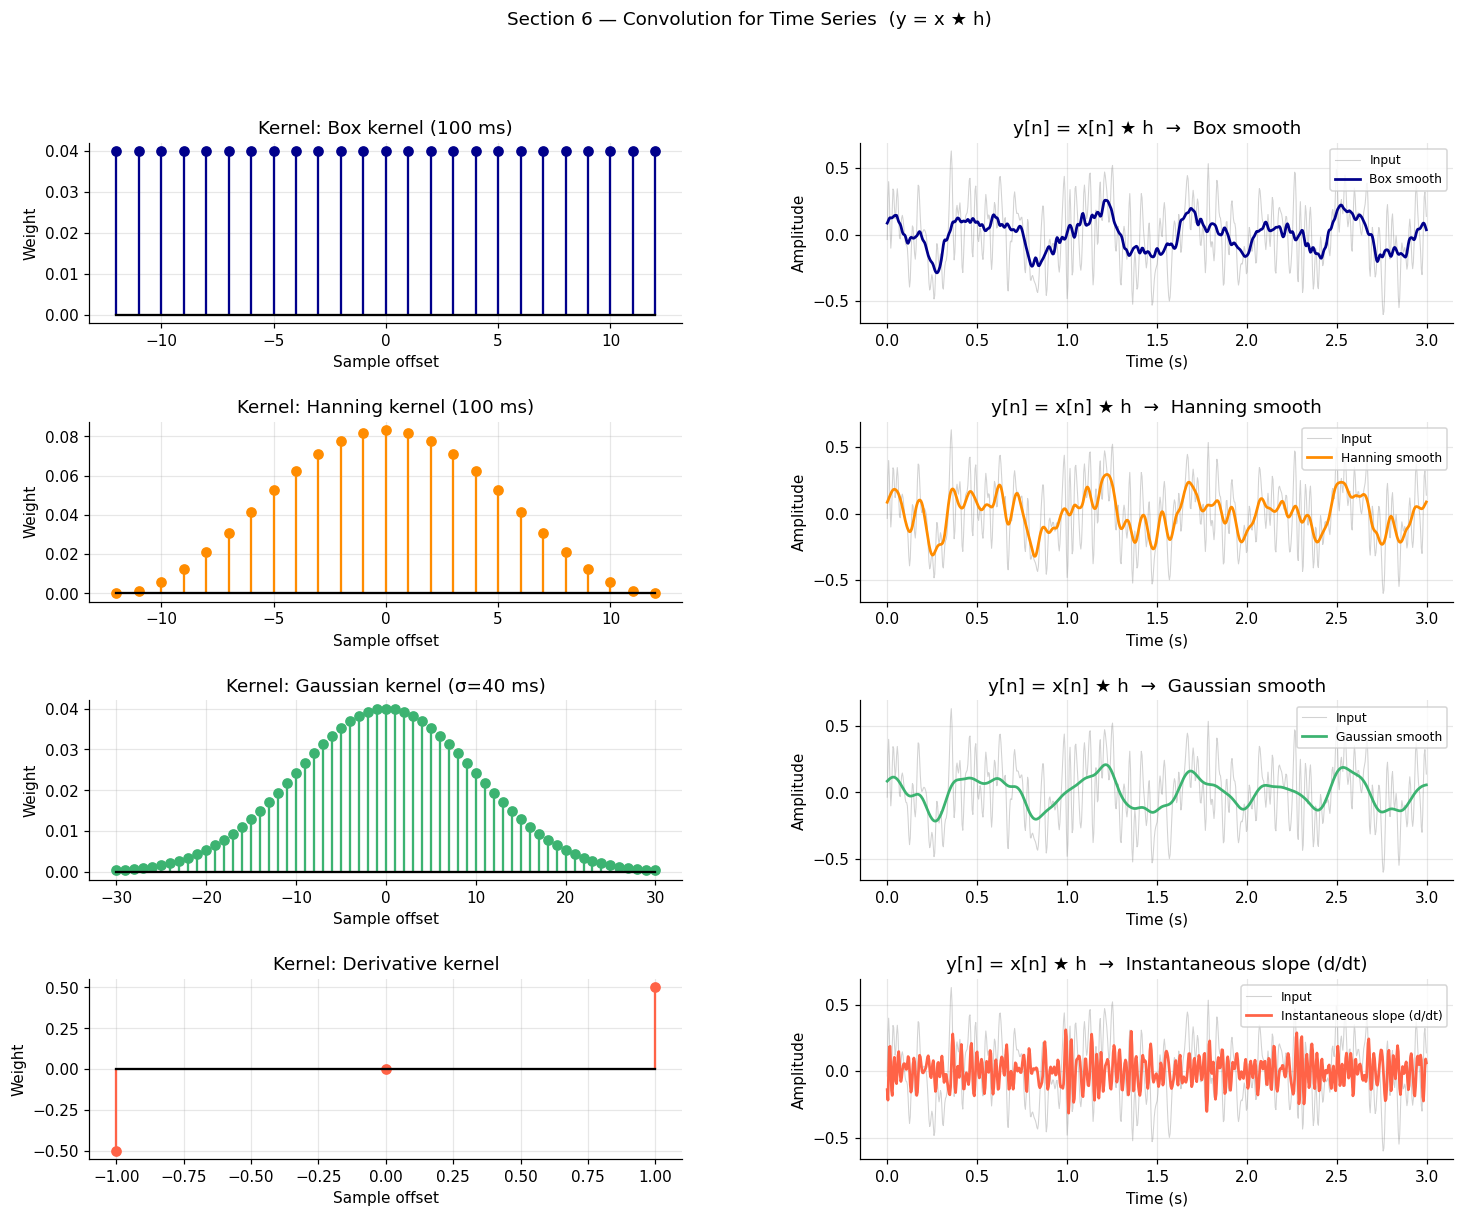

In [15]:
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.55, wspace=0.3)
wn3 = slice(0, int(3 * TARGET_FS))
t   = np.arange(len(x_conv)) / TARGET_FS

kernels = [
    (h_box,   np.arange(N_box) - N_box//2,  "Box kernel (100 ms)",          "darkblue"),
    (h_hann,  np.arange(N_box) - N_box//2,  "Hanning kernel (100 ms)",      "darkorange"),
    (h_gauss, t_k,                           "Gaussian kernel (σ=40 ms)",    "mediumseagreen"),
    (h_deriv, [-1, 0, 1],                    "Derivative kernel",            "tomato"),
]
outputs = [
    (y_box,   "Box smooth",                  "darkblue"),
    (y_hann,  "Hanning smooth",              "darkorange"),
    (y_gauss, "Gaussian smooth",             "mediumseagreen"),
    (y_deriv, "Instantaneous slope (d/dt)",  "tomato"),
]

for row, ((h, t_kk, klbl, col), (y, ylbl, _)) in enumerate(zip(kernels, outputs)):
    ax_k = fig.add_subplot(gs[row, 0])
    ax_s = fig.add_subplot(gs[row, 1])
    ax_k.stem(t_kk, h, linefmt=f'{col}', markerfmt=f'{col}', basefmt='k-')
    ax_k.set_title(f"Kernel: {klbl}")
    ax_k.set_xlabel("Sample offset")
    ax_k.set_ylabel("Weight")

    ax_s.plot(t[wn3], x_conv[wn3], lw=0.7, alpha=0.35, color='gray', label='Input')
    ax_s.plot(t[wn3], y[wn3],      lw=1.8,              color=col,   label=ylbl)
    ax_s.set_title(f"y[n] = x[n] ★ h  →  {ylbl}")
    ax_s.set_xlabel("Time (s)")
    ax_s.set_ylabel("Amplitude")
    ax_s.legend(fontsize=8)

plt.suptitle("Section 6 — Convolution for Time Series  (y = x ★ h)", fontsize=12)
plt.show()

## SECTION 7: FREQUENCY-SWEPT SIGNALS (CHIRP)

A chirp is a sinusoid whose instantaneous frequency changes over time.
### Testing filters:
   - Pass a chirp through a filter → only the desired band survives.
  - Visible in the spectrogram as a sloped line.

 Also models many biological signals: auditory sweeps, motor cortex ramp-ups.

In [16]:
fs_chirp  = TARGET_FS
duration  = 5.0
t_chirp   = np.linspace(0, duration, int(fs_chirp * duration), endpoint=False)

# Linear chirp: 1 → 60 Hz over 5 seconds
chirp_lin  = signal.chirp(t_chirp, f0=1,  t1=duration, f1=60,  method='linear')

# Logarithmic chirp: 1 → 60 Hz (emphasises low frequencies more)
chirp_log  = signal.chirp(t_chirp, f0=1,  t1=duration, f1=60,  method='logarithmic')

# Apply band-pass filter to the chirp
chirp_bp   = butter_filter(chirp_lin, fs_chirp, 'bandpass', [13.0, 30.0])

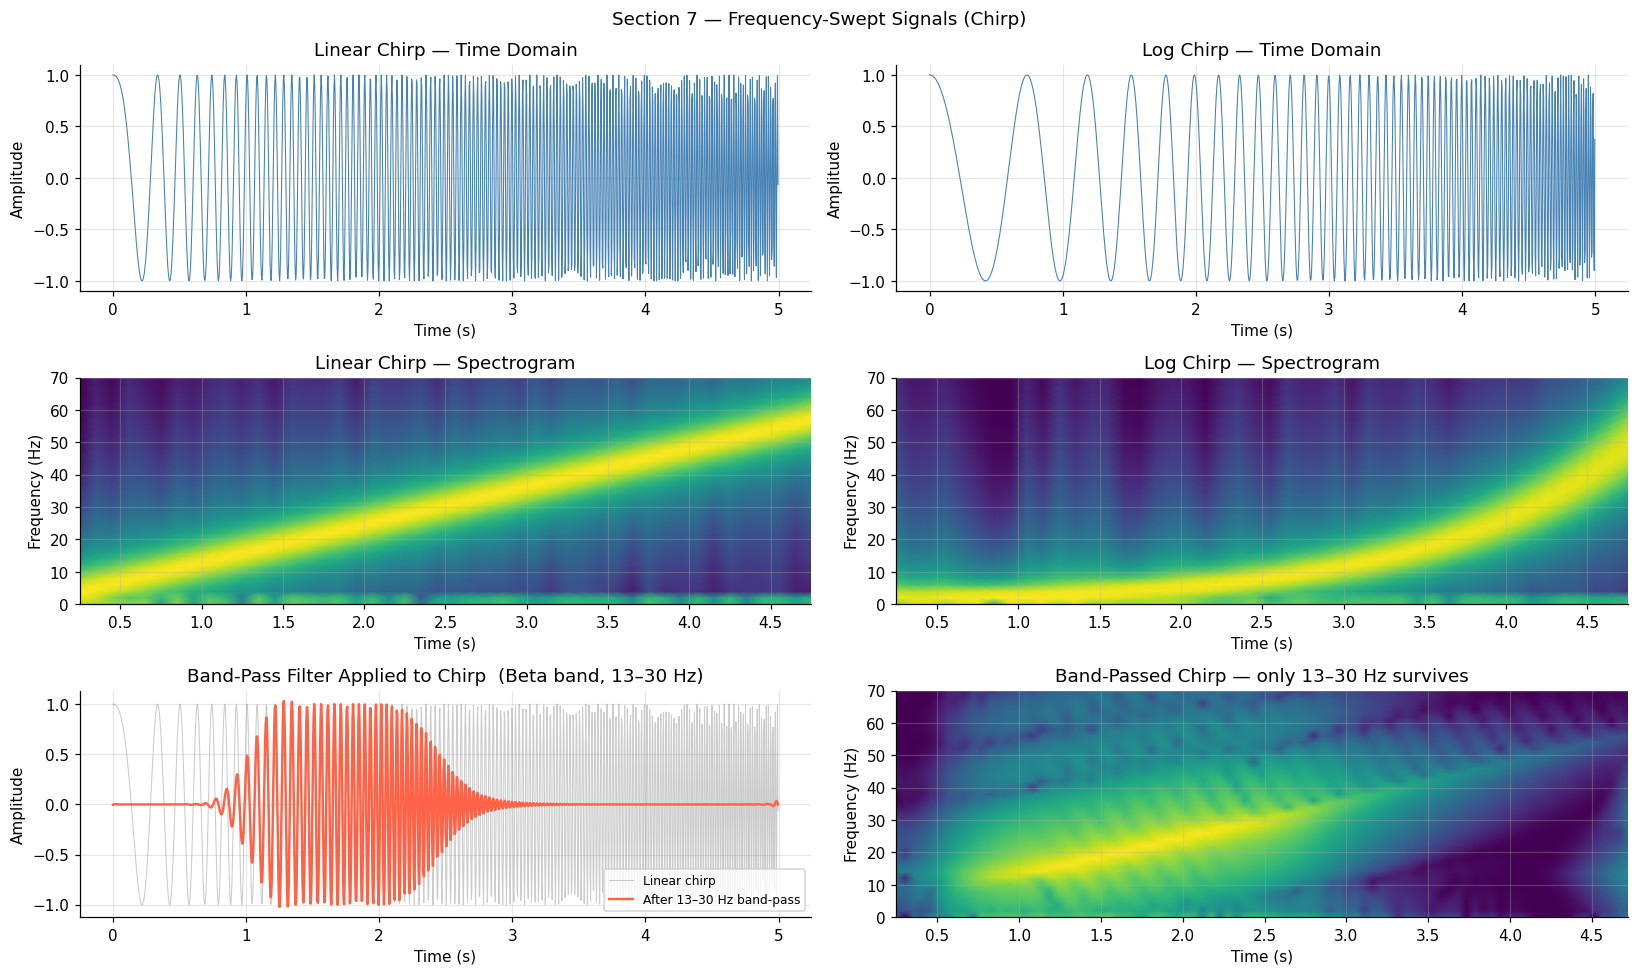

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(15, 9))

for col, (chirp, lbl) in enumerate([(chirp_lin, "Linear Chirp"), (chirp_log, "Log Chirp")]):
    # Time domain
    axes[0, col].plot(t_chirp, chirp, lw=0.7, color='steelblue')
    axes[0, col].set_title(f"{lbl} — Time Domain")
    axes[0, col].set_xlabel("Time (s)")
    axes[0, col].set_ylabel("Amplitude")

    # Spectrogram
    f_c, t_c, Sxx = signal.spectrogram(chirp, fs_chirp,
                                         nperseg=int(fs_chirp * 0.5),
                                         noverlap=int(fs_chirp * 0.4),
                                         window='hann')
    axes[1, col].pcolormesh(t_c, f_c, 10*np.log10(Sxx+1e-12),
                             shading='gouraud', cmap='viridis')
    axes[1, col].set_ylim(0, 70)
    axes[1, col].set_title(f"{lbl} — Spectrogram")
    axes[1, col].set_xlabel("Time (s)")
    axes[1, col].set_ylabel("Frequency (Hz)")

# Band-passed chirp (linear only, both columns share)
axes[2, 0].plot(t_chirp, chirp_lin, lw=0.7, alpha=0.4, color='gray',   label='Linear chirp')
axes[2, 0].plot(t_chirp, chirp_bp,  lw=1.6, color='tomato', label='After 13–30 Hz band-pass')
axes[2, 0].set_title("Band-Pass Filter Applied to Chirp  (Beta band, 13–30 Hz)")
axes[2, 0].set_xlabel("Time (s)")
axes[2, 0].set_ylabel("Amplitude")
axes[2, 0].legend(fontsize=8)

# Frequency response test: pass chirp through the filter, plot output spectrum
f_spec, t_sp, Sxx_bp = signal.spectrogram(chirp_bp, fs_chirp,
                                            nperseg=int(fs_chirp * 0.5),
                                            noverlap=int(fs_chirp * 0.45))
axes[2, 1].pcolormesh(t_sp, f_spec, 10*np.log10(Sxx_bp+1e-12),
                       shading='gouraud', cmap='viridis')
axes[2, 1].set_ylim(0, 70)
axes[2, 1].set_title("Band-Passed Chirp — only 13–30 Hz survives")
axes[2, 1].set_xlabel("Time (s)")
axes[2, 1].set_ylabel("Frequency (Hz)")

plt.suptitle("Section 7 — Frequency-Swept Signals (Chirp)", fontsize=12)
plt.show()

## SECTION 8: KALMAN FILTER (1-D SCALAR)

The Kalman filter is an *optimal* linear recursive estimator for systems with Gaussian noise. It is non-stationary (the gain adapts each step) so it qualifies as a "time-varying linear" filter — sometimes grouped withnon-linear filters in neuroscience.

### Scalar 1-D model (no state dynamics, only observation noise):
-   State transition:  x_k = x_{k-1}          (signal assumed locally constant)
-   Observation:       z_k = x_k + v_k,  v_k ~ N(0, R)

### Update equations:
-  K_k = P_{k|k-1} / (P_{k|k-1} + R)         (Kalman gain)
-   x̂_k = x̂_{k-1} + K_k (z_k - x̂_{k-1})    (state estimate)
-   P_k = (1 - K_k) P_{k|k-1}                  (error covariance)

In [18]:
def kalman_filter_1d(z, Q=1e-4, R=0.1):
    """
    Scalar Kalman filter.
    Q : process noise variance   (small → smoother, slower to adapt)
    R : measurement noise variance (large → more smoothing)
    """
    n        = len(z)
    x_hat    = np.zeros(n)
    P        = np.zeros(n)
    x_hat[0] = z[0]
    P[0]     = 1.0

    for k in range(1, n):
        # Prediction
        x_pred = x_hat[k-1]
        P_pred = P[k-1] + Q
        # Update
        K         = P_pred / (P_pred + R)
        x_hat[k]  = x_pred + K * (z[k] - x_pred)
        P[k]      = (1 - K) * P_pred

    return x_hat

# Apply to the bandpass-filtered rest signal
rest_kalman_smooth  = kalman_filter_1d(rest_filt, Q=1e-5, R=0.05)
rest_kalman_noisy   = kalman_filter_1d(rest_filt, Q=1e-2, R=0.5)



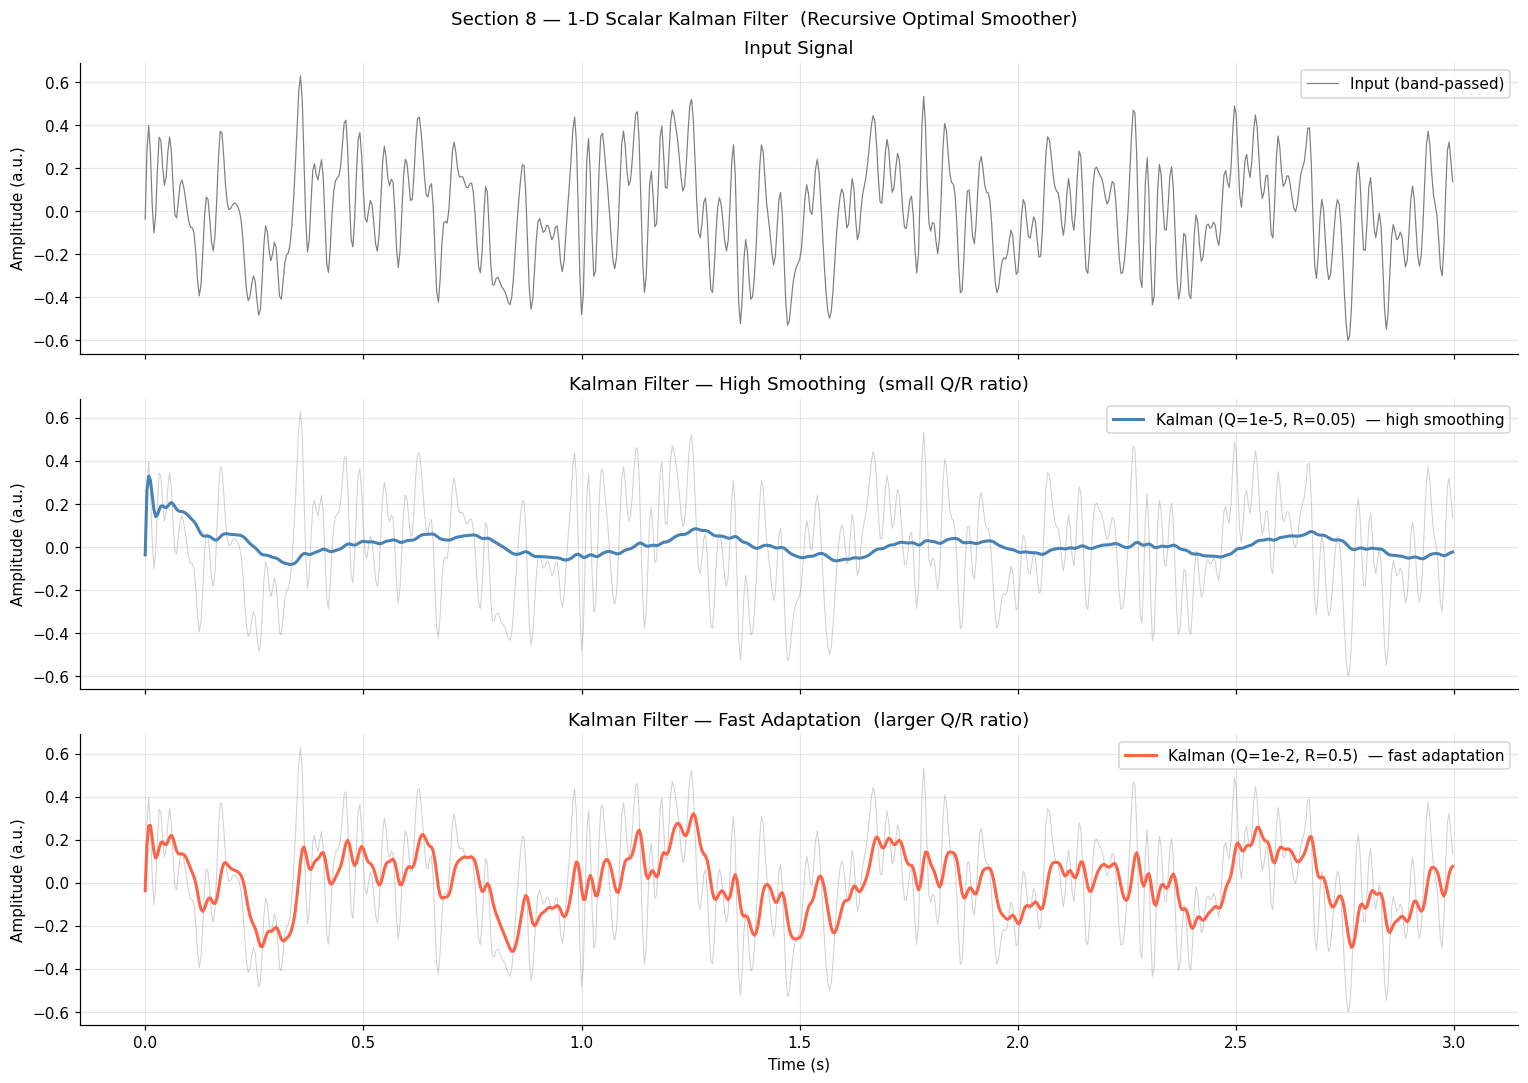

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
wn3 = slice(0, int(3 * TARGET_FS))
t   = np.arange(len(rest_filt)) / TARGET_FS

axes[0].plot(t[wn3], rest_filt[wn3], lw=0.8, color='gray', label='Input (band-passed)')
axes[0].set_title("Input Signal")
axes[0].legend()

axes[1].plot(t[wn3], rest_filt[wn3],         lw=0.7, alpha=0.35, color='gray')
axes[1].plot(t[wn3], rest_kalman_smooth[wn3], lw=2.0, color='steelblue',
             label='Kalman (Q=1e-5, R=0.05)  — high smoothing')
axes[1].set_title("Kalman Filter — High Smoothing  (small Q/R ratio)")
axes[1].legend()

axes[2].plot(t[wn3], rest_filt[wn3],        lw=0.7, alpha=0.35, color='gray')
axes[2].plot(t[wn3], rest_kalman_noisy[wn3], lw=2.0, color='tomato',
             label='Kalman (Q=1e-2, R=0.5)  — fast adaptation')
axes[2].set_title("Kalman Filter — Fast Adaptation  (larger Q/R ratio)")
axes[2].set_xlabel("Time (s)")
axes[2].legend()

for ax in axes:
    ax.set_ylabel("Amplitude (a.u.)")

plt.suptitle("Section 8 — 1-D Scalar Kalman Filter  (Recursive Optimal Smoother)", fontsize=12)
plt.show()

## SECTION 9: Z-SCORE NORMALISATION

> z[n] = (x[n] - μ) / σ

- Centres the signal at 0, scales variance to 1.
- Allows comparison of "relative modulation" across conditions/subjects.

- Do NOT z-score separately when absolute power differences matter.
-   Use percent-change or dB baseline normalisation instead.

In [20]:
def zscore(sig_in):
    mu, sigma = np.mean(sig_in), np.std(sig_in)
    return sig_in if sigma < 1e-12 else (sig_in - mu) / sigma

rest_z = zscore(rest_filt)
move_z = zscore(move_filt)

print("\n[Z-Score]")
for lbl, z in [("Rest", rest_z), ("Move", move_z)]:
    outliers = (np.abs(z) > 3).sum()
    print(f"  {lbl}: mean={np.mean(z):.2e}  std={np.std(z):.4f}  "
          f"|z|>3: {outliers}/{len(z)} ({100*outliers/len(z):.1f}%)")


[Z-Score]
  Rest: mean=-8.05e-18  std=1.0000  |z|>3: 16/3750 (0.4%)
  Move: mean=-9.47e-18  std=1.0000  |z|>3: 6/3750 (0.2%)


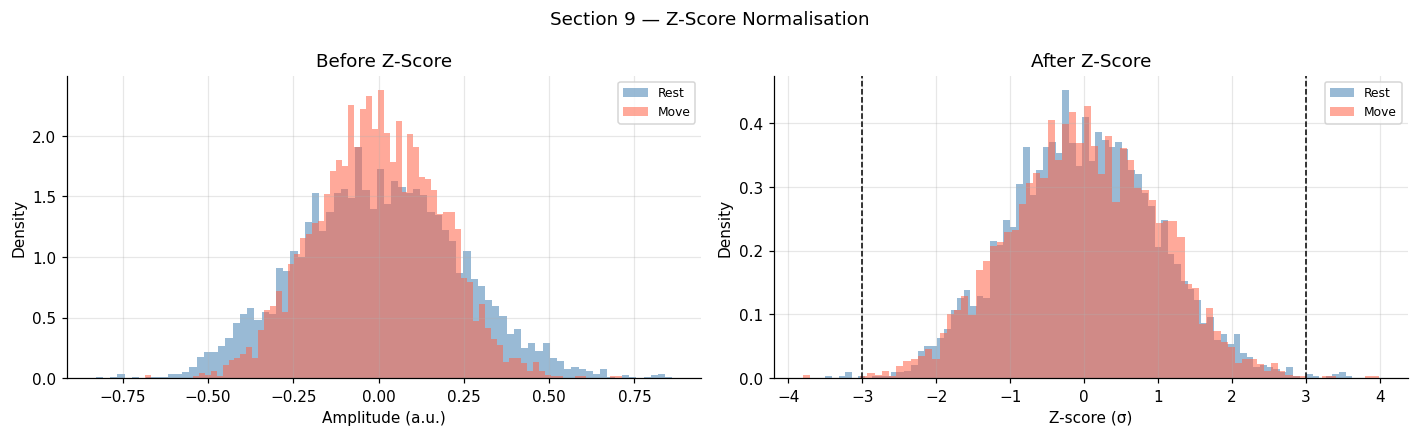

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, before, lbl in [(axes[0], True, "Before Z-Score"), (axes[1], False, "After Z-Score")]:
    r = rest_filt if before else rest_z
    m = move_filt if before else move_z
    ax.hist(r, bins=80, color='steelblue', alpha=0.55, label='Rest', density=True)
    ax.hist(m, bins=80, color='tomato',    alpha=0.55, label='Move', density=True)
    if not before:
        for thr in [-3, 3]:
            ax.axvline(thr, color='black', ls='--', lw=1)
        ax.set_xlabel("Z-score (σ)")
    else:
        ax.set_xlabel("Amplitude (a.u.)")
    ax.set_ylabel("Density")
    ax.set_title(lbl)
    ax.legend(fontsize=8)
plt.suptitle("Section 9 — Z-Score Normalisation", fontsize=12)
plt.show()

## SECTION 10: POWER SPECTRAL DENSITY (WELCH'S METHOD)

### Welch (1967):
1. Divide signal into overlapping windows of length L.
2. Apply window function (Hann) to reduce spectral leakage.
3. Compute |FFT|² per window.
4. Average → variance ↓ by ≈ number of windows.

 Frequency resolution:  Δf = fs / L
 nperseg = fs × 2  →  Δf = 0.5 Hz   (good for Beta sub-band separation)

### Expected neuro pattern at M1:
- Beta (13–30 Hz): dominant at rest, suppressed (ERD) during movement.

In [22]:
nperseg  = int(TARGET_FS * 2)   # 2-second windows
noverlap = nperseg // 2         # 50 % overlap

freqs_r, psd_rest = signal.welch(rest_z, TARGET_FS,
                                  nperseg=nperseg, noverlap=noverlap,
                                  window='hann', scaling='density')
freqs_m, psd_move = signal.welch(move_z, TARGET_FS,
                                  nperseg=nperseg, noverlap=noverlap,
                                  window='hann', scaling='density')

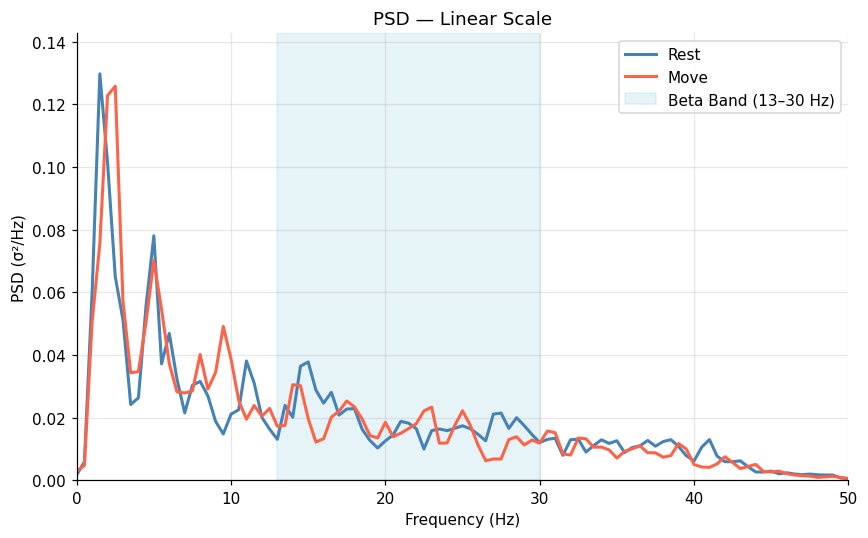

In [69]:
# Plot 1: Linear Scale
# Best for seeing the absolute magnitude of the dominant low frequencies
plt.figure(figsize=(8, 5))
plt.plot(freqs_r, psd_rest, color='steelblue', lw=2, label='Rest')
plt.plot(freqs_m, psd_move, color='tomato',    lw=2, label='Move')
plt.axvspan(13, 30, color='lightblue', alpha=0.30, label='Beta Band (13–30 Hz)')
plt.xlim(0, 50)
plt.ylim(0, np.max(psd_rest) * 1.1) # Auto-scale y-axis to fit the peak
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (σ²/Hz)")
plt.title("PSD — Linear Scale")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

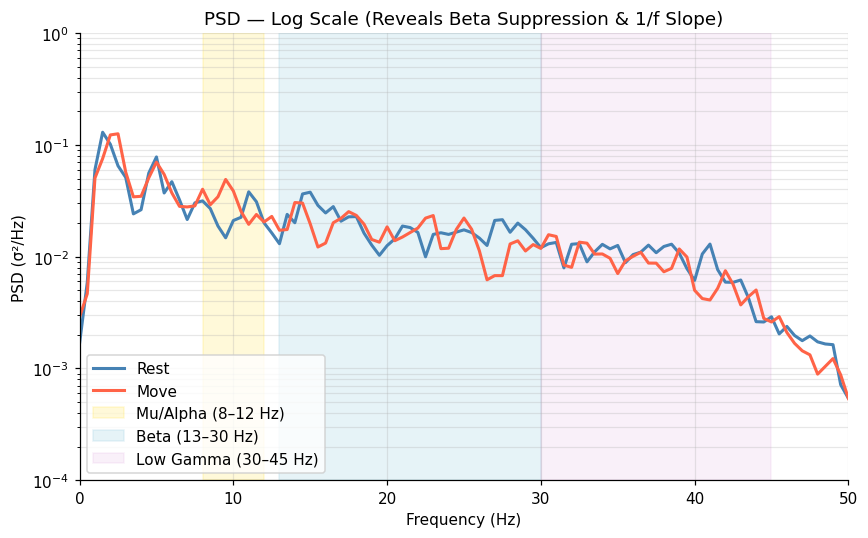

In [68]:
# Plot 2: Logarithmic Scale
# Best for visualizing the entire spectrum and identifying suppression across bands
plt.figure(figsize=(8, 5))
plt.semilogy(freqs_r, psd_rest, color='steelblue', lw=2, label='Rest')
plt.semilogy(freqs_m, psd_move, color='tomato',    lw=2, label='Move')
plt.axvspan( 8, 12, color='gold',      alpha=0.15, label='Mu/Alpha (8–12 Hz)')
plt.axvspan(13, 30, color='lightblue', alpha=0.30, label='Beta (13–30 Hz)')
plt.axvspan(30, 45, color='plum',      alpha=0.15, label='Low Gamma (30–45 Hz)')
plt.xlim(0, 50)
plt.ylim(1e-4, 1e-0) # Set fixed limits to show the "noise floor" vs "signal"
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (σ²/Hz)")
plt.title("PSD — Log Scale (Reveals Beta Suppression & 1/f Slope)")
plt.legend(loc='lower left') # Move legend to avoid obscuring the Beta drop
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## SECTION 11: BETA-BAND ERD QUANTIFICATION

- Band power = integral of PSD over the band (trapezoidal rule).
- ERD% = (P_move - P_rest) / P_rest × 100
- Negative ERD% → suppression (desynchronisation) during movement.

In [24]:
bands = {
    'Delta (1–4 Hz)':    (1,  4),
    'Theta (4–8 Hz)':    (4,  8),
    'Mu/Alpha (8–12)':   (8,  12),
    'Beta (13–30 Hz)':   (13, 30),
    'Low Gamma (30–45)': (30, 45),
}

print("\n[Band Power]")
print(f"  {'Band':<22}  {'Rest':>10}  {'Move':>10}  {'ERD %':>8}")
print("  " + "-" * 58)
for bname, (lo, hi) in bands.items():
    mask = (freqs_r >= lo) & (freqs_r <= hi)
    pr   = np.trapezoid(psd_rest[mask], freqs_r[mask])
    pm   = np.trapezoid(psd_move[mask], freqs_m[mask])
    erd  = (pm - pr) / pr * 100
    flag = " ← ERD" if erd < -15 else (" ← ERS" if erd > 15 else "")
    print(f"  {bname:<22}  {pr:>10.4f}  {pm:>10.4f}  {erd:>7.1f}%{flag}")

beta_mask = (freqs_r >= 13) & (freqs_r <= 30)
beta_r    = np.trapezoid(psd_rest[beta_mask], freqs_r[beta_mask])
beta_m    = np.trapezoid(psd_move[beta_mask], freqs_m[beta_mask])
erd_pct   = (beta_m - beta_r) / beta_r * 100


[Band Power]
  Band                          Rest        Move     ERD %
  ----------------------------------------------------------
  Delta (1–4 Hz)              0.2074      0.2291     10.5%
  Theta (4–8 Hz)              0.1655      0.1673      1.1%
  Mu/Alpha (8–12)             0.0995      0.1252     25.8% ← ERS
  Beta (13–30 Hz)             0.3225      0.2831    -12.2%
  Low Gamma (30–45)           0.1438      0.1257    -12.6%


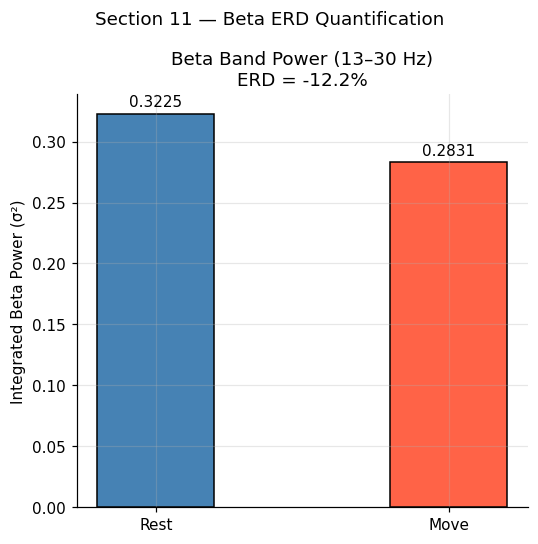

In [25]:
fig, ax = plt.subplots(figsize=(5, 5))
bars = ax.bar(['Rest', 'Move'], [beta_r, beta_m],
              color=['steelblue', 'tomato'], edgecolor='black', width=0.4)
for bar, val in zip(bars, [beta_r, beta_m]):
    ax.text(bar.get_x() + bar.get_width()/2, val*1.02,
            f"{val:.4f}", ha='center', fontsize=10)
ax.set_ylabel("Integrated Beta Power (σ²)")
ax.set_title(f"Beta Band Power (13–30 Hz)\nERD = {erd_pct:.1f}%")
plt.suptitle("Section 11 — Beta ERD Quantification", fontsize=12)
plt.show()

## SECTION 12: SPECTROGRAM (TIME-FREQUENCY ANALYSIS)
 
### Why Spectrograms?
PSD averages power over the entire time series segment (15 seconds). It tells us *what* frequencies are present, but not *when*.
 
**Spectrograms** (Short-Time Fourier Transform) slides a window across the signal to show how frequency content evolves over time.
 
### The Trade-off:
 - **Wide Window**: Better Frequency Resolution, Worse Time Resolution.
 - **Narrow Window**: Better Time Resolution, Worse Frequency Resolution.
 
 > For Beta band (13-30Hz), we need at least ~1 second of data to resolve the frequency clearly.

In [35]:
from scipy.ndimage import gaussian_filter
from typing import Tuple, Optional

def smooth_spectrogram(Sxx: np.ndarray, sigma: Tuple[float, float] = (1.0, 1.0)) -> np.ndarray:
    """
    Apply 2D Gaussian smoothing to a spectrogram matrix (n_freqs, n_times).
    sigma = (freq_sigma, time_sigma) in units of bins.
    """
    if sigma is None:
        return Sxx
    return gaussian_filter(Sxx, sigma=sigma)

In [61]:
def plot_spectrogram(sig, fs, title):
    """
    Computes STFT, Smooths, and plots in dB scale with improved contrast.
    """
    nperseg = int(fs * 1.0)  # 1-second window
    noverlap = int(nperseg * 0.75) 
    
    f, t, Sxx = signal.spectrogram(sig, fs, nperseg=nperseg, noverlap=noverlap, window='hann')
    
    # Smooth the spectrogram
    Sxx_smooth = smooth_spectrogram(Sxx, sigma=(1.0, 2.0))
    
    # Convert to Decibels
    Sxx_db = 10 * np.log10(Sxx_smooth + 1e-12)
    
    # Set dynamic color limits to improve contrast
    # We set vmin to the 5th percentile to make the background darker, 
    # highlighting the active frequencies.
    vmin = np.percentile(Sxx_db, 70)
    vmax = np.percentile(Sxx_db, 99)
    
    plt.figure(figsize=(12, 6))
    # 'plasma' or 'inferno' often provides better visual contrast for dB scales than viridis
    mesh = plt.pcolormesh(t, f, Sxx_db, shading='gouraud', cmap='plasma', vmin=vmin, vmax=vmax)
    
    plt.ylim([12, 50])
    plt.ylabel('Frequency (Hz)')
    plt.xlabel('Time (sec)')
    plt.title(title)
    cbar = plt.colorbar(mesh, label='Power (dB)')
    plt.show()

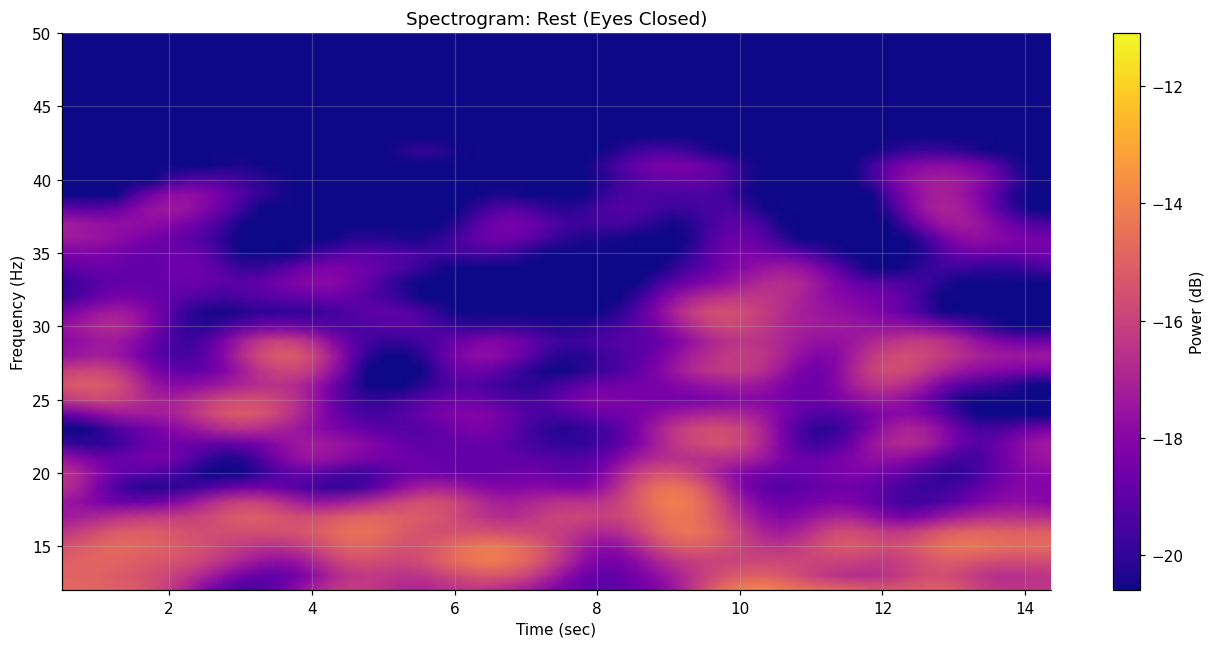

In [62]:
# Plot Rest Spectrogram
plot_spectrogram(rest_z, TARGET_FS, "Spectrogram: Rest (Eyes Closed)")

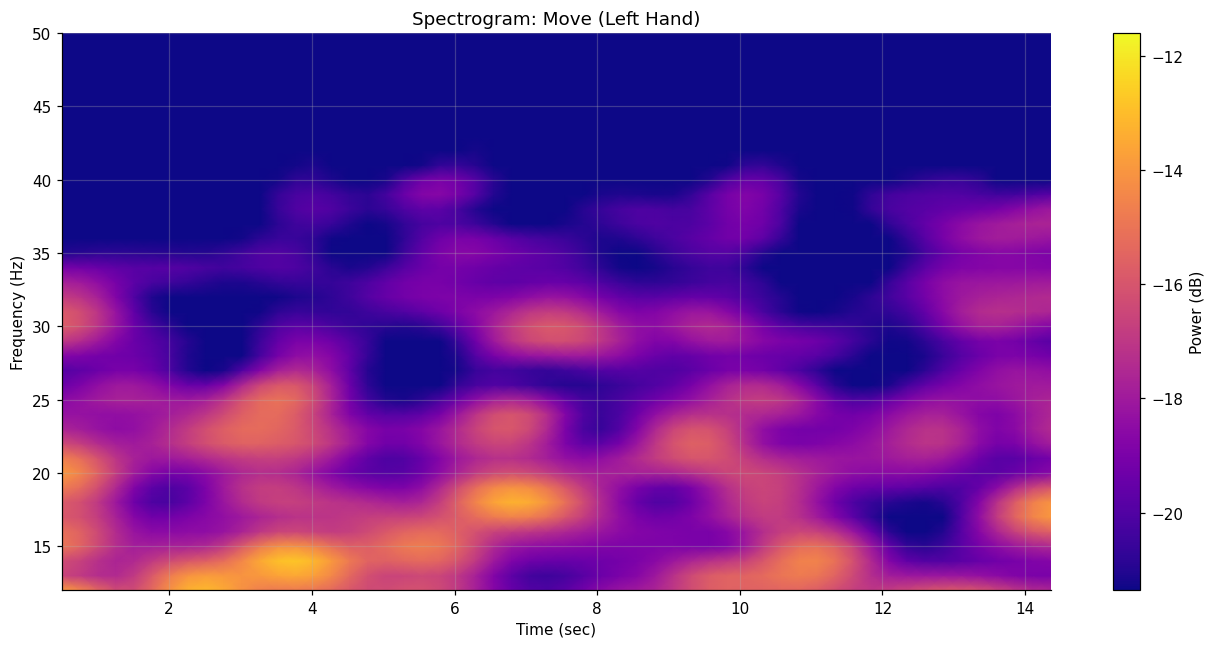

In [63]:
# Plot Move Spectrogram
plot_spectrogram(move_z, TARGET_FS, "Spectrogram: Move (Left Hand)")

### Differential Spectrogram (ERD Visualization)

**Event-Related Desynchronization (ERD)**, we can subtract the Rest spectrogram from the Move spectrogram.

- **Blue**: Power Decrease (Suppression/ERD)
- **Red**: Power Increase (Rebound/ERS)

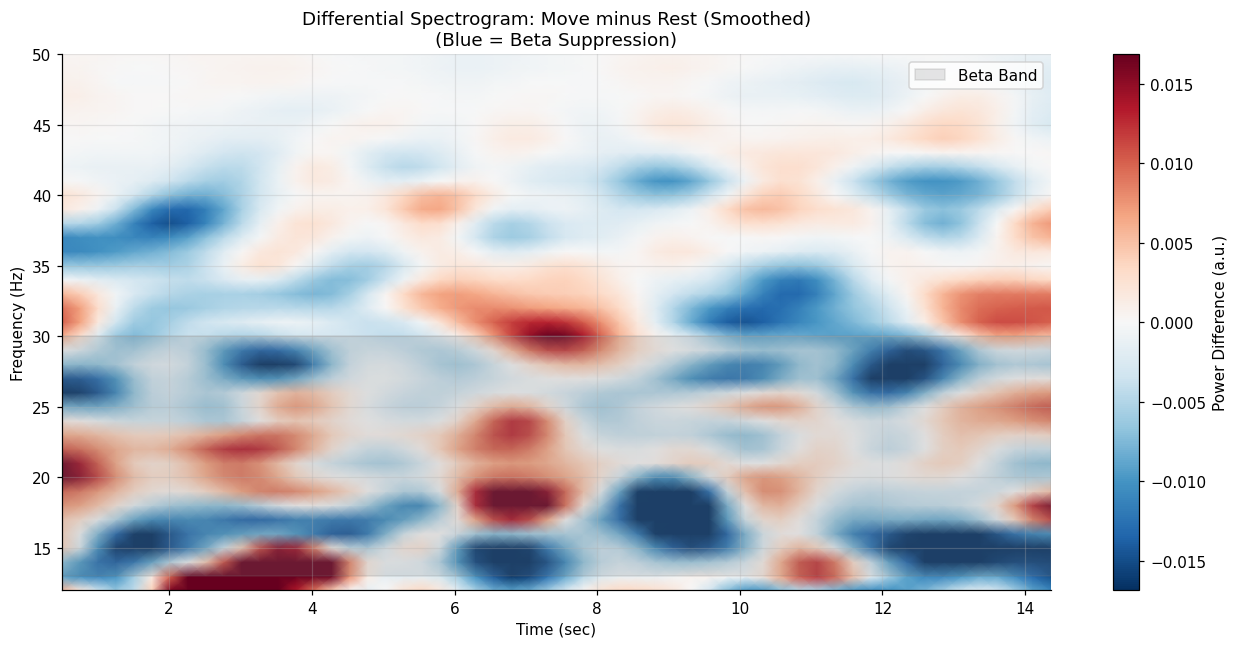

In [64]:
def plot_differential_spectrogram(sig_rest, sig_move, fs):
    nperseg = int(fs * 1.0)
    noverlap = int(nperseg * 0.75)
    
    # Compute Spectrograms
    f, t, Sxx_rest = signal.spectrogram(sig_rest, fs, nperseg=nperseg, noverlap=noverlap)
    _, _, Sxx_move = signal.spectrogram(sig_move, fs, nperseg=nperseg, noverlap=noverlap)
    
    # Calculate Difference (Move - Rest)
    Sxx_diff = Sxx_move - Sxx_rest
    
    # Apply 2D Gaussian Smoothing to the difference map
    # sigma=(1.0, 1.0) means 1 bin in freq, 1 bin in time
    Sxx_diff_smooth = smooth_spectrogram(Sxx_diff, sigma=(1.0, 2.0))
    
    plt.figure(figsize=(12, 6))
    # Use RdBu_r colormap for symmetric difference (Blue=Neg, Red=Pos)
    vmax = np.percentile(np.abs(Sxx_diff_smooth), 95)
    mesh = plt.pcolormesh(t, f, Sxx_diff_smooth, shading='gouraud', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    
    plt.ylim([12, 50])
    plt.ylabel('Frequency (Hz)')
    plt.xlabel('Time (sec)')
    plt.title("Differential Spectrogram: Move minus Rest (Smoothed)\n(Blue = Beta Suppression)")
    plt.colorbar(mesh, label='Power Difference (a.u.)')
    plt.axhspan(13, 30, color='gray', alpha=0.2, label='Beta Band')
    plt.legend(loc='upper right')
    plt.show()

plot_differential_spectrogram(rest_z, move_z, TARGET_FS)

